In [21]:
!pip install ultralytics opencv-python


In [36]:
!pip install ultralytics


In [42]:
from ultralytics import YOLO

lane_model = YOLO("yolov8n-seg.pt")  # incluye segmentación


In [47]:
from ultralytics import YOLO
import cv2

car_model = YOLO("/content/best.pt")  #modelo entrenado carros


In [48]:
from ultralytics import YOLO

lane_model = YOLO("yolov8n-seg.pt")   # modelo base para segmentación

lane_model.train(
    data="dataset-lanes.yaml",
    imgsz=640,
    epochs=60,
    batch=8
)


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset-lanes.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

RuntimeError: Dataset 'dataset-lanes.yaml' error ❌ 'dataset-lanes.yaml' does not exist

In [51]:
import kagglehub


path = kagglehub.dataset_download("trainingdatapro/roads-segmentation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'roads-segmentation-dataset' dataset.
Path to dataset files: /kaggle/input/roads-segmentation-dataset


In [52]:
import os

for root, dirs, files in os.walk(path, topdown=True):
    print(root)
    for d in dirs:
        print("   DIR:", d)
    for f in files:
        print("   FILE:", f)
    break


/kaggle/input/roads-segmentation-dataset
   DIR: images
   DIR: masks
   FILE: roads_segmentation.csv
   FILE: annotations.xml


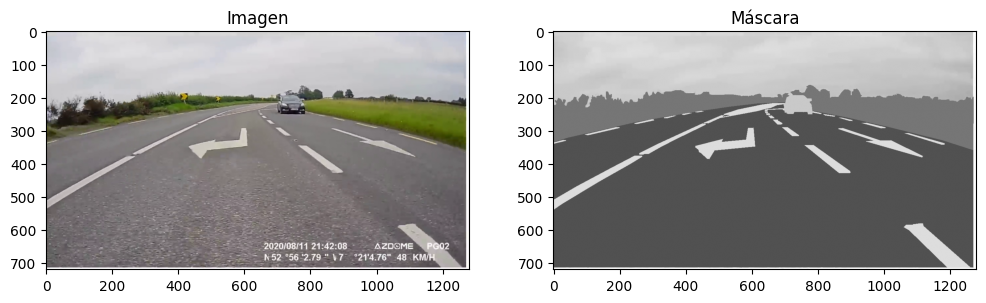

In [53]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

dataset_dir = Path(path)
img_dir = dataset_dir / "images"
mask_dir = dataset_dir / "masks"

img = cv2.imread(str(img_dir/"0.png"))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(str(mask_dir/"0.png"), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Imagen")
plt.subplot(1,2,2); plt.imshow(mask, cmap="gray"); plt.title("Máscara")
plt.show()


In [54]:
from pathlib import Path

base_dir = Path("/kaggle/input/roads-segmentation-dataset")

images_dir = base_dir / "images"
masks_dir  = base_dir / "masks"

print(images_dir, masks_dir)


/kaggle/input/roads-segmentation-dataset/images /kaggle/input/roads-segmentation-dataset/masks


In [56]:
import os
import cv2
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil

# Rutas
images = sorted(list(images_dir.glob("*.png")))
masks  = sorted(list(masks_dir.glob("*.png")))

# Salida en formato YOLO
output = Path("/kaggle/working/roads_yolo")
(output / "images/train").mkdir(parents=True, exist_ok=True)
(output / "images/val").mkdir(parents=True, exist_ok=True)
(output / "labels/train").mkdir(parents=True, exist_ok=True)
(output / "labels/val").mkdir(parents=True, exist_ok=True)

# Train/Val split
train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

def get_mask_path(img_path):
    return masks_dir / img_path.name  # porque el dataset tiene mismo nombre 1.png, 1.png

def process(img_list, split):
    for img_path in img_list:
        mask_path = get_mask_path(img_path)

        # Copiar imagen
        new_img_path = output / f"images/{split}/{img_path.name}"
        shutil.copy(img_path, new_img_path)

        # Leer máscara
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        # Encontrar contornos
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        h, w = mask.shape
        label_path = output / f"labels/{split}/{img_path.stem}.txt"

        with open(label_path, "w") as f:
            for c in contours:
                # YOLO pide contorno plano normalizado
                polygon = c.reshape(-1, 2)
                polygon = polygon.astype(float)
                polygon[:, 0] /= w
                polygon[:, 1] /= h

                poly_str = " ".join([f"{x:.6f} {y:.6f}" for x, y in polygon])
                f.write(f"0 {poly_str}\n")   # clase 0 = road

process(train_imgs, "train")
process(val_imgs, "val")

print("Conversión terminada. Dataset listo en:", output)


Conversión terminada. Dataset listo en: /kaggle/working/roads_yolo


In [57]:
yaml_content = """
path: /kaggle/working/roads_yolo
train: images/train
val: images/val

names:
  0: road
"""

with open("/kaggle/working/roads_yolo/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("dataset.yaml creado.")


dataset.yaml creado.


In [58]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

model.train(
    data="/kaggle/working/roads_yolo/dataset.yaml",
    imgsz=640,
    batch=8,
    epochs=50
)


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/roads_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78ba543a41a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 


image 1/1 /content/carril39.png: 352x640 (no detections), 7.6ms
Speed: 2.0ms preprocess, 7.6ms inference, 0.6ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/carril39.png: 352x640 4 roads, 14.4ms
Speed: 1.9ms preprocess, 14.4ms inference, 2.6ms postprocess per image at shape (1, 3, 352, 640)


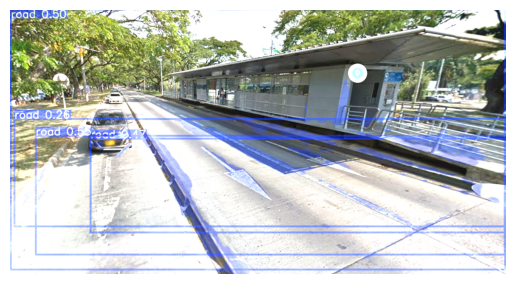

In [61]:
from ultralytics import YOLO
import cv2

car_model = YOLO("/content/best.pt")
lane_model = YOLO("/content/Ultra-Fast-Lane-Detection/Ultra-Fast-Lane-Detection/YOLOP/YOLOP/runs/segment/train2/weights/best.pt")

img = "/content/carril39.png"

cars = car_model(img)[0].plot()
lanes = lane_model(img)[0].plot()

# superposición
combined = cv2.addWeighted(lanes, 0.7, cars, 1.0, 0)

plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
